In [5]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\dell\.kaggle\kaggle.json"


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
import zipfile

zip_path = "loan-status-prediction.zip"
extract_to = "loan_status_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")


Unzipped successfully!


In [7]:
import warnings

warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv(r'C:\Users\dell\Downloads\MLDeployment\loan_status_data\loan_data.csv')

In [20]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [22]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [23]:
df.drop(columns='Loan_ID',inplace=True)

In [24]:
df.isna().sum()

Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [25]:

numerical_columns = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

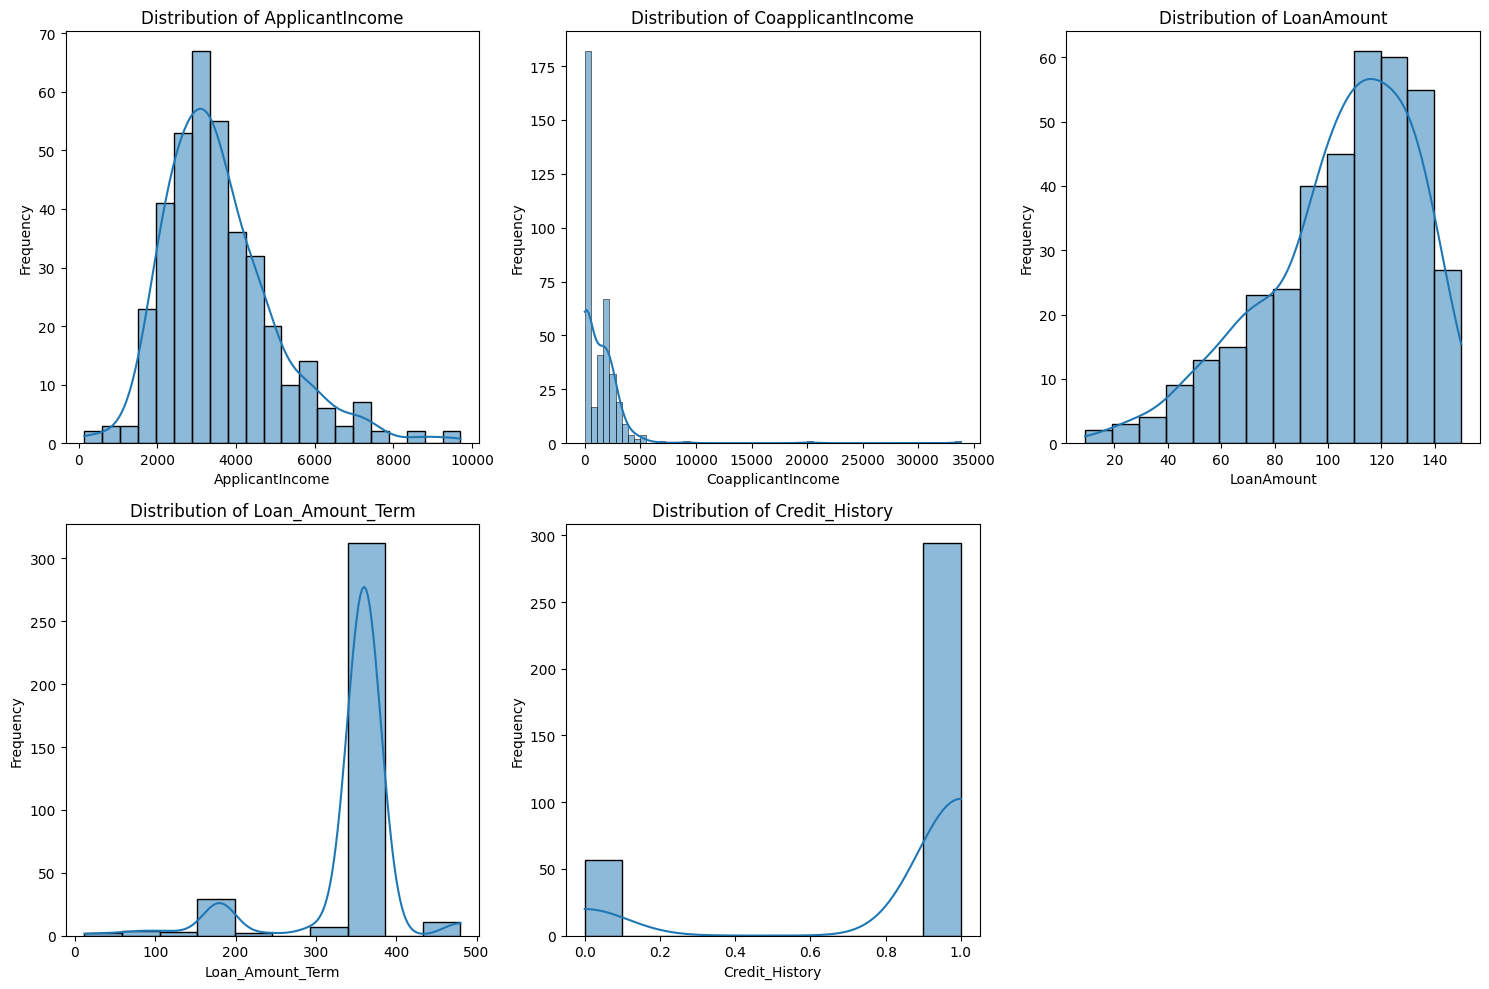

In [26]:

n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [27]:
for i in numerical_columns:
    UpperBound = df[i].mean() + 3 * df[i].std()
    LowerBound = df[i].mean() - 3 * df[i].std()
    # outliers BEFORE replacement
    outliers_before = df[(df[i] > UpperBound) | (df[i] < LowerBound)]
    print(f"{i} - Outliers before: {len(outliers_before)}")
    # Replace outliers
    df.loc[df[i] > UpperBound, i] = UpperBound
    df.loc[df[i] < LowerBound, i] = LowerBound
    # outliers AFTER replacement
    outliers_after = df[(df[i] > UpperBound) | (df[i] < LowerBound)]
    print(f"{i} - Outliers after: {len(outliers_after)}\n")


ApplicantIncome - Outliers before: 4
ApplicantIncome - Outliers after: 0

CoapplicantIncome - Outliers before: 3
CoapplicantIncome - Outliers after: 0

LoanAmount - Outliers before: 2
LoanAmount - Outliers after: 0

Loan_Amount_Term - Outliers before: 9
Loan_Amount_Term - Outliers after: 0

Credit_History - Outliers before: 0
Credit_History - Outliers after: 0



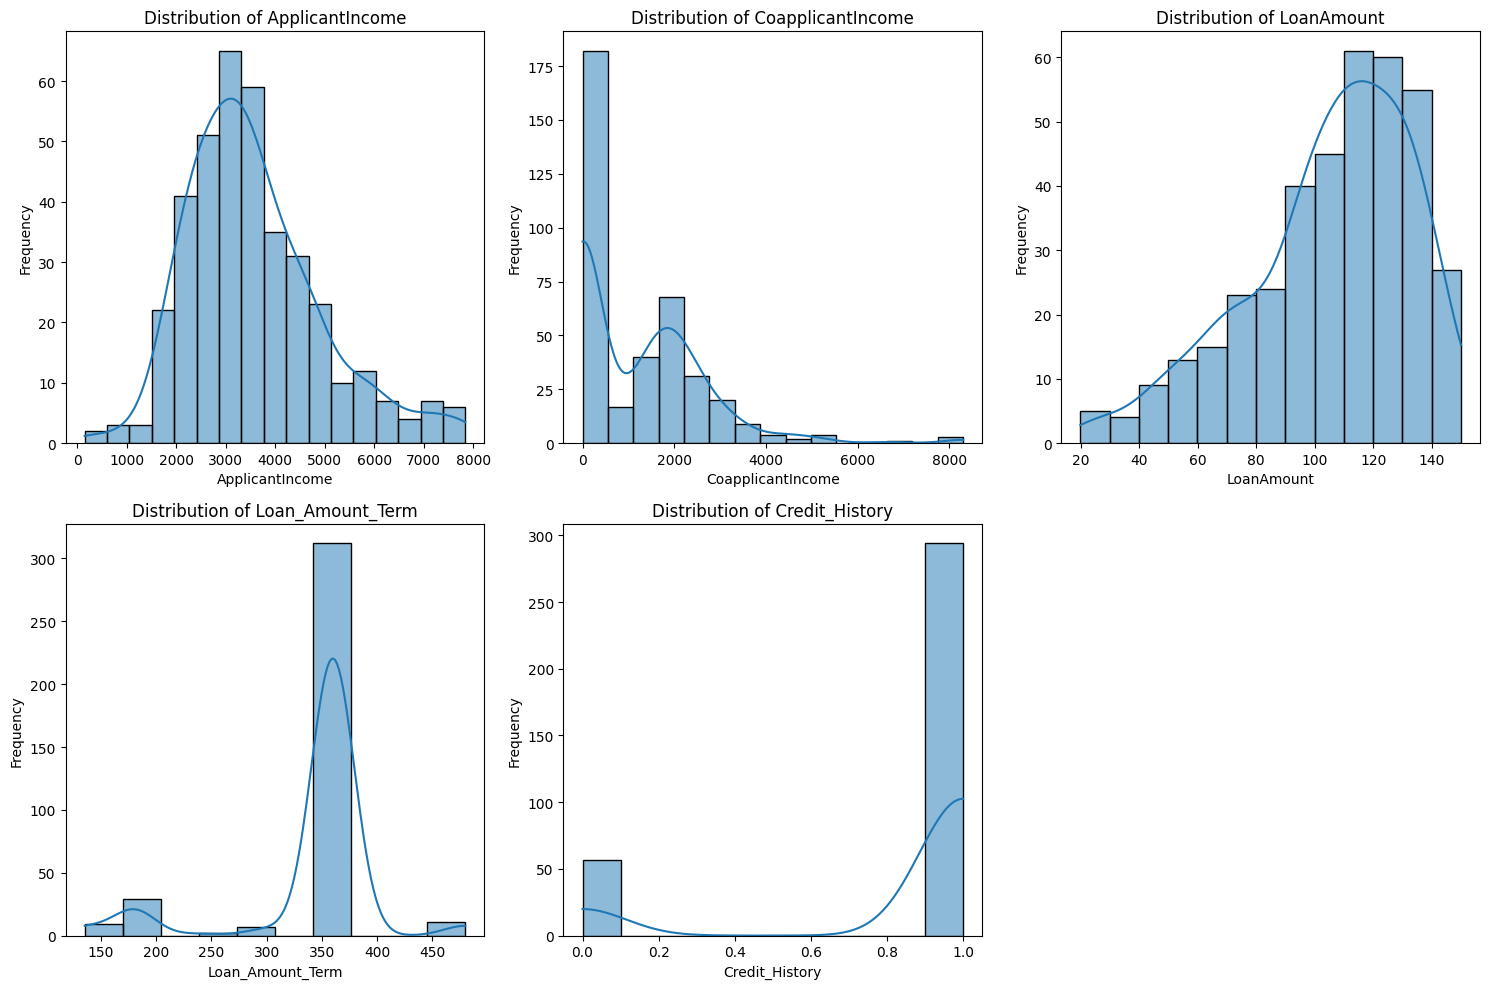

In [28]:

n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [29]:
numericalMissData=['Loan_Amount_Term','Credit_History']
for col in numericalMissData:
    df[col]=df[col].fillna(df[col].median())

In [30]:
CatMissData=['Gender','Dependents','Self_Employed']
for col in CatMissData:
    df[col]=df[col].fillna(df[col].mode()[0])

In [31]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [32]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y


In [33]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,381.000000,381.000000
mean,3566.609308,1177.753567,105.023157,342.721664,0.850394
std,1372.555102,1410.809848,28.243160,62.681360,0.357154
min,150.000000,0.000000,19.911486,135.217093,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,7839.286599,8299.729722,150.000000,480.000000,1.000000


### EDA

In [34]:
print(df[numerical_columns].describe())


       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       381.000000         381.000000  381.000000        381.000000   
mean       3566.609308        1177.753567  105.023157        342.721664   
std        1372.555102        1410.809848   28.243160         62.681360   
min         150.000000           0.000000   19.911486        135.217093   
25%        2600.000000           0.000000   90.000000        360.000000   
50%        3333.000000         983.000000  110.000000        360.000000   
75%        4288.000000        2016.000000  127.000000        360.000000   
max        7839.286599        8299.729722  150.000000        480.000000   

       Credit_History  
count      381.000000  
mean         0.850394  
std          0.357154  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [35]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Loan_Status']


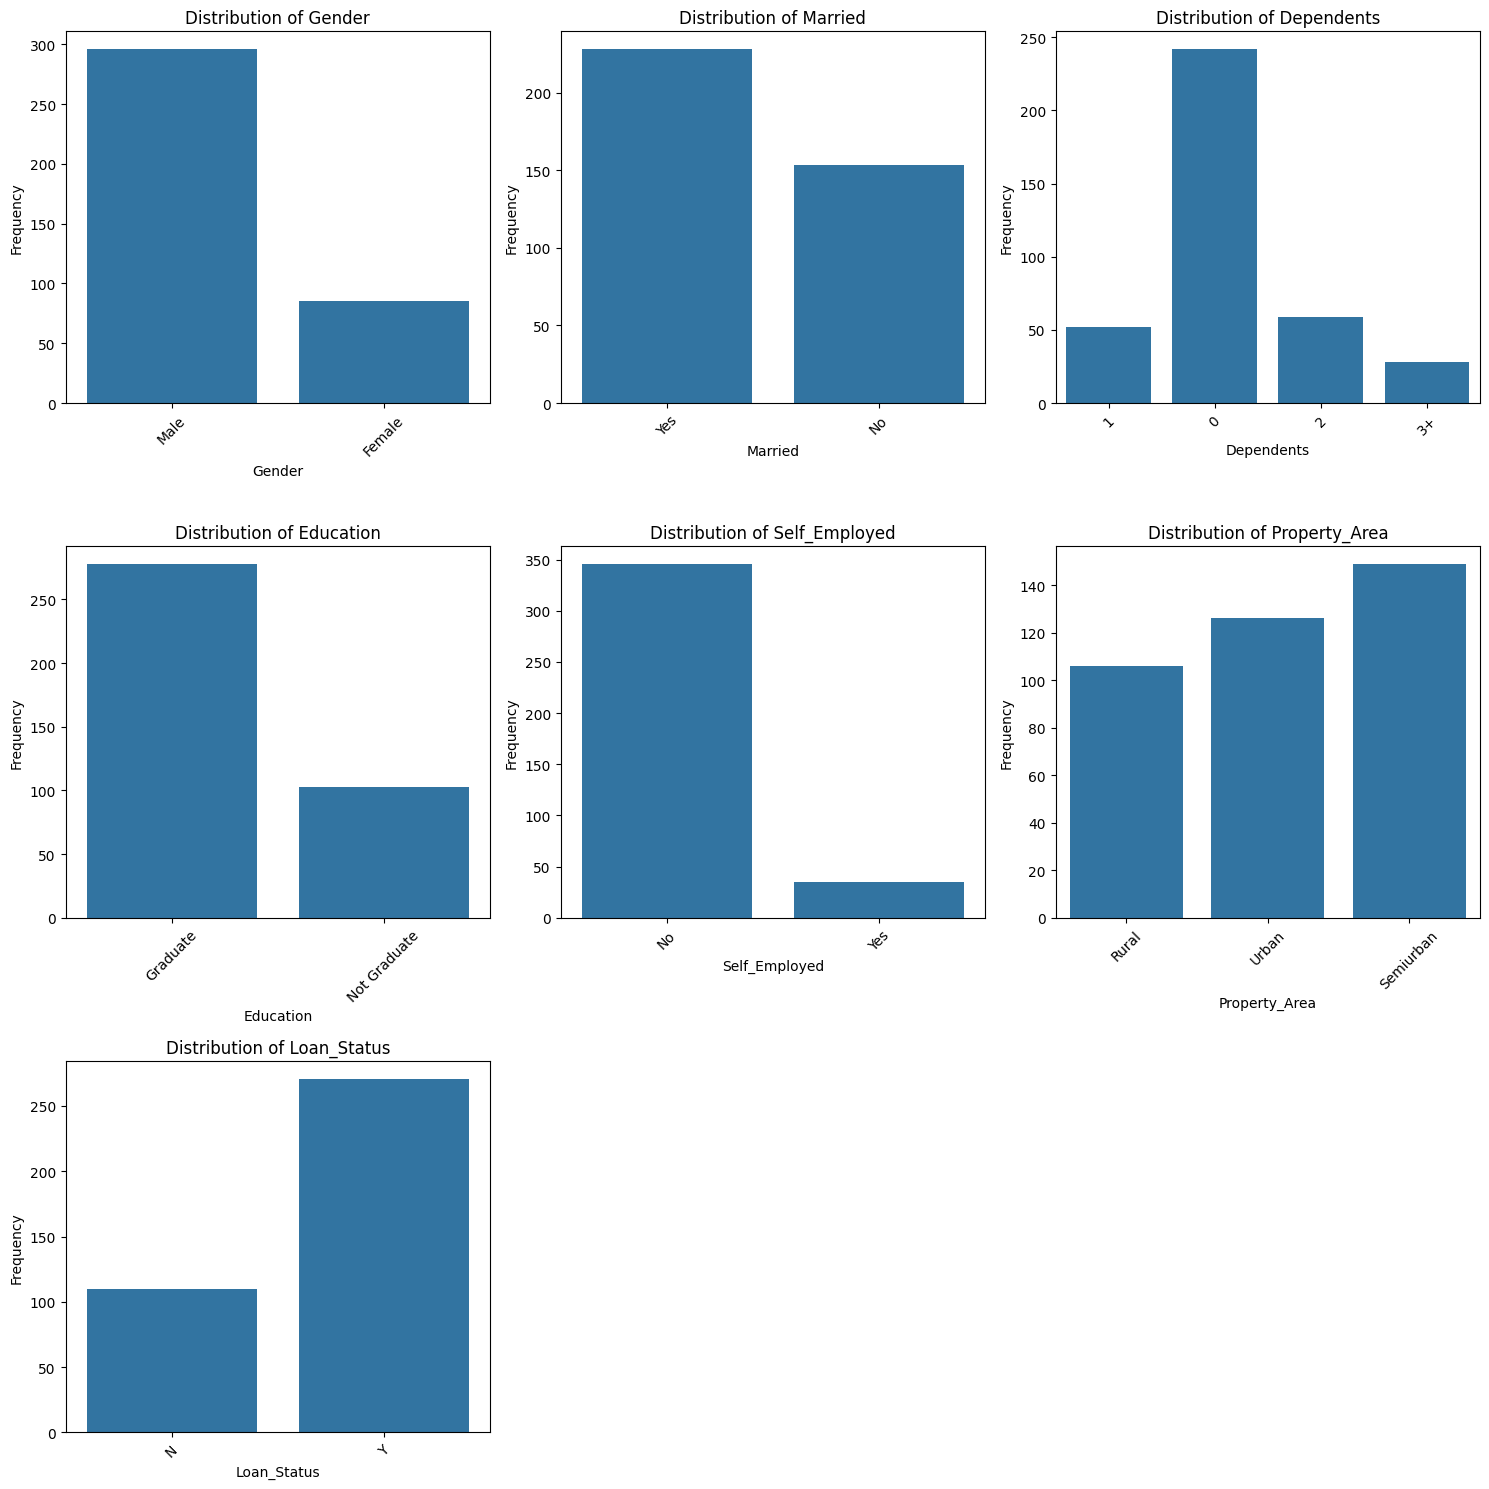

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])  # Removed kde=True
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=45)  # Rotate labels for readability

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [37]:
# Encoding
encoding={
    'Gender': {'Male':1 , 'Female': 0}, 
    'Married': {'Yes': 1, 'No': 0},
    'Dependents': {'0':0, '1':1, '2': 2, '3+': 4},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0},
    'Property_Area':{'Semiurban':0,'Urban':1,'Rural':2}
}

In [38]:
df.replace(encoding, inplace=True)

### Feature Selection


In [39]:
x = df[['Credit_History', 'Married', 'CoapplicantIncome', 'Education', 'Dependents', 'Gender']]
y = df['Loan_Status']

In [40]:
print(df['Loan_Status'].value_counts())


1    271
0    110
Name: Loan_Status, dtype: int64


### Coorelation Matrix


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Show correlations with target only
print("Correlation with Loan_Status:\n", corr_matrix['Loan_Status'].sort_values(ascending=False))


Correlation with Loan_Status:
 Loan_Status          1.000000
Credit_History       0.609630
Married              0.092473
CoapplicantIncome    0.074936
Education            0.055586
LoanAmount           0.039967
Gender               0.020302
Dependents           0.011901
ApplicantIncome     -0.016669
Self_Employed       -0.017947
Loan_Amount_Term    -0.049577
Property_Area       -0.167368
Name: Loan_Status, dtype: float64


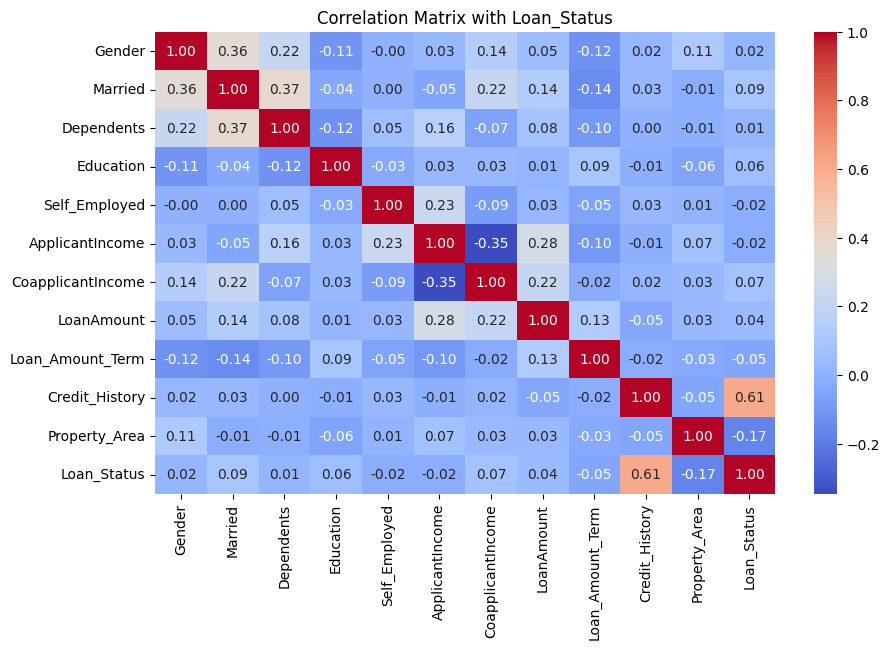

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix with Loan_Status")
plt.show()


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd


### Variance Inflation Factor (VIF)
Check Multicollinearity

VIF = 1: No multicollinearity

VIF > 5: Moderate multicollinearity (watch out)

VIF > 10: Serious multicollinearity (drop or combine features)


In [44]:
# Step 3: Add constant


# Step 4: Calculate VIF
vif = pd.DataFrame()
vif["Feature"] = x.columns
vif["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print(vif)


             Feature       VIF
0     Credit_History  4.085170
1            Married  3.354189
2  CoapplicantIncome  1.829998
3          Education  2.834471
4         Dependents  1.693509
5             Gender  4.299925


### Check linearity

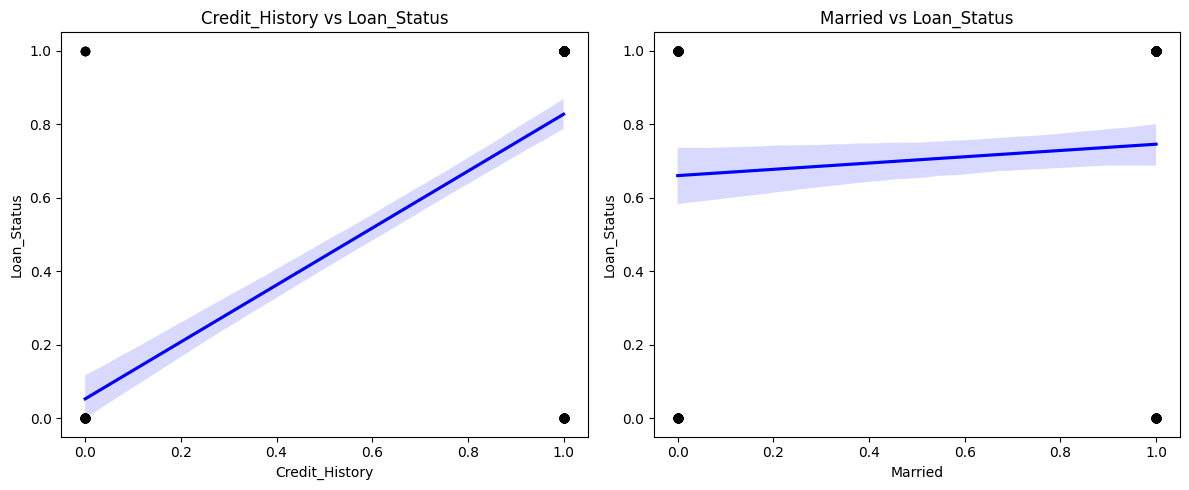

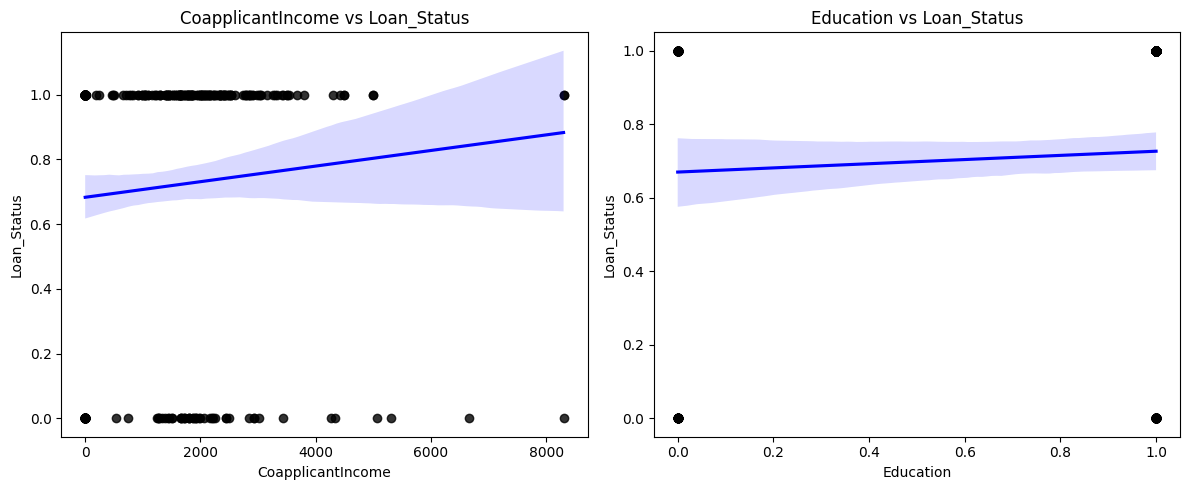

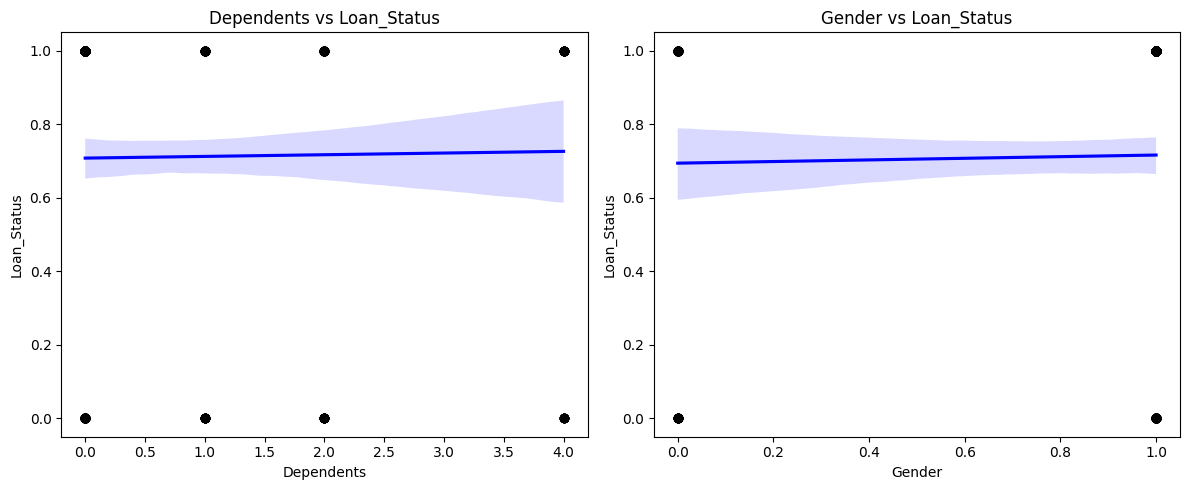

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

features = x.columns  
target = y.name       
n = len(features)


for i in range(0, n, 2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # First plot
    sns.regplot(x=features[i], y=target, data=df, ax=axes[0], 
                scatter_kws={"color": "black"}, line_kws={"color": "blue"})
    axes[0].set_title(f'{features[i]} vs {target}')

    # Second plot (only if it exists)
    if i + 1 < n:
        sns.regplot(x=features[i+1], y=target, data=df, ax=axes[1], 
                    scatter_kws={"color": "black"}, line_kws={"color": "blue"})
        axes[1].set_title(f'{features[i+1]} vs {target}')
    else:
        fig.delaxes(axes[1])  # Remove empty subplot if odd number of features

    plt.tight_layout()
    plt.show()


### Split Data

In [46]:
x

,Credit_History,Married,CoapplicantIncome,Education,Dependents,Gender
0,1.0,1,1508.0,1,1,1
1,1.0,1,0.0,1,0,1
2,1.0,1,2358.0,0,0,1
3,1.0,0,0.0,1,0,1
4,1.0,1,1516.0,0,0,1
...,...,...,...,...,...,...
376,1.0,1,0.0,1,4,1
377,1.0,1,1950.0,1,0,1
378,1.0,0,0.0,1,0,0
379,1.0,1,0.0,1,4,1


In [47]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)  # x is your features DataFrame

# Convert scaled NumPy array back to a DataFrame
x = pd.DataFrame(x_scaled, columns=x.columns)
x

,Credit_History,Married,CoapplicantIncome,Education,Dependents,Gender
0,1.0,1.0,0.181693,1.0,0.25,1.0
1,1.0,1.0,0.000000,1.0,0.00,1.0
2,1.0,1.0,0.284106,0.0,0.00,1.0
3,1.0,0.0,0.000000,1.0,0.00,1.0
4,1.0,1.0,0.182657,0.0,0.00,1.0
...,...,...,...,...,...,...
376,1.0,1.0,0.000000,1.0,1.00,1.0
377,1.0,1.0,0.234947,1.0,0.00,1.0
378,1.0,0.0,0.000000,1.0,0.00,0.0
379,1.0,1.0,0.000000,1.0,1.00,1.0


In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

### Model Selection

In [49]:
len(x)

381

In [50]:
from sklearn.ensemble import RandomForestClassifier

# Create the model with custom parameters
model = RandomForestClassifier(
    n_estimators=10, min_samples_split=10, max_depth=7
)

# Fit to training data
model.fit(x_train, y_train)



RandomForestClassifier(max_depth=7, min_samples_split=10, n_estimators=10)

In [51]:
print("Accuracy is", model.score(x_test, y_test)*100)

Accuracy is 84.61538461538461


In [52]:
from sklearn.model_selection import cross_val_score

# cross validation - it is used for better validation of model
# eg: cv-5, train-4, test-1
score = cross_val_score(model, x, y, cv=5)
print("Cross validation is",np.mean(score)*100)

Cross validation is 84.25153793574847


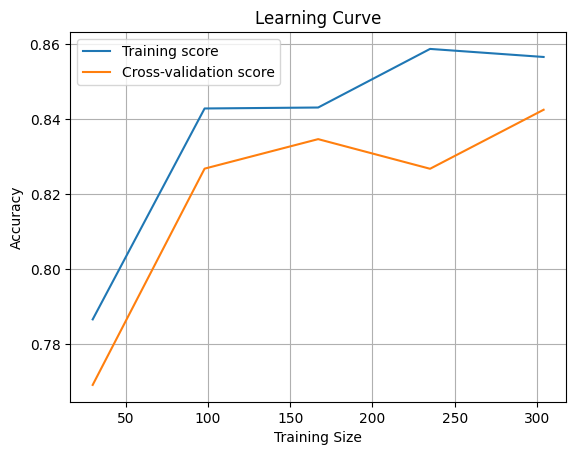

In [53]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    model, x, y, cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.title('Learning Curve')
plt.show()



In [54]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 6,  6],
       [ 0, 27]], dtype=int64)

<Axes: >

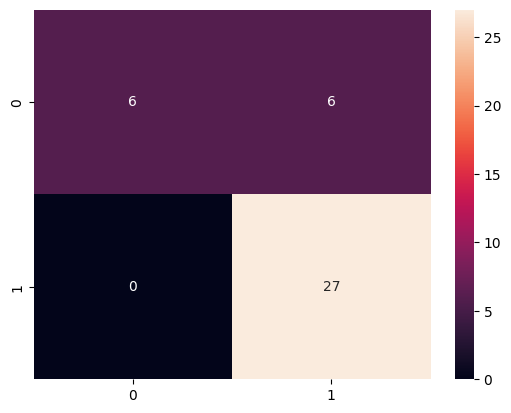

In [55]:
sns.heatmap(cm, annot=True)

In [56]:
import pickle
pickle.dump(model,open('model.pkl','wb'))


In [63]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [64]:
mod = pickle.load(open('model.pkl','rb'))

new_data = pd.DataFrame([{
    'Credit_History': 1,
    'Married': 'Yes',
    'CoapplicantIncome': 1500,
    'Education': 'Graduate',
    'Dependents': '0',
    'Gender': 'Male'
}])

# Apply encoding
for col in encoding:
    if col in new_data.columns:
        new_data[col] = new_data[col].map(encoding[col])

# Scale with same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = mod.predict(new_data_scaled)
print("Predicted Loan Status:", "Approved" if prediction[0] == 1 else "Rejected")



Predicted Loan Status: Approved


array([1], dtype=int64)